link tableu : `https://public.tableau.com/app/profile/daniswara.eka.saputra/viz/DashboardAnalisisPenjualanParfumeMendieBay/Dashboard1?publish=yes`

### Analisis Penjualan Parfum Pria di e-commerce eBay 

<center><img src="parfume.png" height=384, width=384></img></center>

Penjualan parfum di platform seperti eBay semakin kompetitif, dengan banyaknya pilihan merek dan harga yang ber aneka ragam. Bagi penjual, memahami tren pasar dan preferensi pelanggan sangat penting untuk tetap bersaing. Faktor seperti harga, merek, dan ketersediaan produk mempengaruhi keputusan pembelian konsumen. Dengan menganalisis data mengenai harga dan merek yang populer, penjual dapat lebih mudah menyesuaikan strategi mereka dan akhirnya nanti dapat meningkatkan penjualan.

### Defining the Problem Statements

Using SMART framework:

1. **Specific**: Analisis harga, ketersediaan, dan preferensi brand dalam parfum pria di eBay.

2. **Measurable**: Mengukur harga rata-rata, jumlah listing, ketersediaan, dan ranking brand.

3. **Achievable**: Menggunakan data yang tersedia dan teknik analisis eksplorasi serta memberikan insight yang berguna.

4. **Relevant**: Memberikan wawasan yang berguna untuk penjual parfum agar dapat menghasilkan revenue yang lebih tinggi.

5. **Time-Bound**: Menyelesaikan analisis dalam 1 minggu.

`Problem statement`:


Tujuannya adalah untuk memberikan wawasan yang dapat berguna untuk penjual parfum mengenai pasar parfum di eBay dengan menganalisis harga, ketersediaan, dan preferensi brand parfum pria. Analisis ini akan membantu penjual parfum mengoptimalkan listing mereka, meningkatkan strategi penetapan harga, dan mengikuti tren pasar, yang pada akhirnya meningkatkan pendapatan mereka.


### Breaking Down the Problem

Main problem: `Penjual parfum kurang memahami bagaimana harga, ketersediaan, dan preferensi brand mempengaruhi daya saing produk mereka.`

Untuk memudahkan analisis disini kita akan menggunakan framework `5W+1H` dalam memecahkan masalah.

The `5W+1H`s:
- Berapa harga rata-rata parfum pria di eBay, dan bagaimana perbedaannya berdasarkan brand?
- brand parfum apa saja yang paling diminati?
- Barang apa yang membawa revenue paling tinggi? 
- Bagaimana ketersediaan parfum berkorelasi dengan harga?
- brand parfum mana yang paling banyak terdaftar di eBay 
- Apakah semakin langka mempengaruhi pembelian?




### Overview Dataset
Kumpulan Data E-Commerce Parfum 2024 terdiri dari informasi terperinci tentang 1000 daftar parfum pria yang bersumber dari eBay. Dataset ini memberikan gambaran komprehensif tentang tren pasar saat ini, harga, ketersediaan, dan distribusi geografis parfum di ruang e-commerce.

### Import Libraries

In [20]:
import pandas as pd
import numpy as np
from scipy import stats
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

### Data Loading
Bagian ini berisi proses penyiapan data dan menampilkan data. 

sumber dataset = 'https://www.kaggle.com/datasets/kanchana1990/perfume-e-commerce-dataset-2024/data'

In [2]:
data = pd.read_csv('ebay_mens_perfume.csv')
data

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"
...,...,...,...,...,...,...,...,...,...,...
995,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Eau de Toilette,20.28,US $20.28/ea,45.0,"45 available / 1,613 sold",1613.0,"May 24, 2024 08:14:07 PDT","Dallas, Texas, United States"
996,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Eau de Toilette,30.58,US $30.58,10.0,More than 10 available / 31 sold,31.0,"May 23, 2024 08:39:30 PDT",United States
997,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Eau de Toilette,39.99,US $39.99/ea,2.0,2 available / 305 sold,305.0,"May 23, 2024 15:27:18 PDT","Jamaica, New York, United States"
998,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Eau de Toilette,9.99,US $9.99/ea,2.0,2 available / 22 sold,22.0,"May 20, 2024 13:20:54 PDT","Lincoln Park, Michigan, United States"


In [4]:
data.describe()

,price,available,sold
count,1000.000000,889.000000,994.000000
mean,46.481200,20.046119,766.266600
std,35.527862,61.547985,3200.971733
min,3.000000,2.000000,1.000000
25%,22.990000,5.000000,14.000000
50%,35.710000,10.000000,49.500000
75%,59.000000,10.000000,320.500000
max,259.090000,842.000000,54052.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               997 non-null    object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          889 non-null    float64
 6   availableText      997 non-null    object 
 7   sold               994 non-null    float64
 8   lastUpdated        947 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.2+ KB


### Data Cleaning
Bagian ini berisi proses penyiapan data berupa data cleaning sebelum dilakukan explorasi data lebih lanjut.

In [6]:
data['currency'] = data['priceWithCurrency'].apply(lambda x:x[:2])
data

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,currency
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States",US
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada",US
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States",US
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States",US
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States",US
...,...,...,...,...,...,...,...,...,...,...,...
995,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Eau de Toilette,20.28,US $20.28/ea,45.0,"45 available / 1,613 sold",1613.0,"May 24, 2024 08:14:07 PDT","Dallas, Texas, United States",US
996,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Eau de Toilette,30.58,US $30.58,10.0,More than 10 available / 31 sold,31.0,"May 23, 2024 08:39:30 PDT",United States,US
997,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Eau de Toilette,39.99,US $39.99/ea,2.0,2 available / 305 sold,305.0,"May 23, 2024 15:27:18 PDT","Jamaica, New York, United States",US
998,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Eau de Toilette,9.99,US $9.99/ea,2.0,2 available / 22 sold,22.0,"May 20, 2024 13:20:54 PDT","Lincoln Park, Michigan, United States",US


Pada code diatas kita akan membuat kolom baru 'currency' , kolom ini dibuat untuk nantinya memisahkan currency di kolom 'priceWithCurrency'

In [7]:
data_cleaning = data[data['currency'] != 'C ']

Disini kita membuang currency 'C' karena tidak dibutuhkan.

In [10]:
data_cleaning.reset_index(drop=True)

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,currency
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States",US
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada",US
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States",US
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States",US
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States",US
...,...,...,...,...,...,...,...,...,...,...,...
992,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Eau de Toilette,20.28,US $20.28/ea,45.0,"45 available / 1,613 sold",1613.0,"May 24, 2024 08:14:07 PDT","Dallas, Texas, United States",US
993,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Eau de Toilette,30.58,US $30.58,10.0,More than 10 available / 31 sold,31.0,"May 23, 2024 08:39:30 PDT",United States,US
994,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Eau de Toilette,39.99,US $39.99/ea,2.0,2 available / 305 sold,305.0,"May 23, 2024 15:27:18 PDT","Jamaica, New York, United States",US
995,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Eau de Toilette,9.99,US $9.99/ea,2.0,2 available / 22 sold,22.0,"May 20, 2024 13:20:54 PDT","Lincoln Park, Michigan, United States",US


In [23]:
data_cleaning['Kelangkaan Barang'] = data_cleaning[['sold','available']].sum(axis=1)
data_cleaning['Kelangkaan Barang']

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3356\1534259166.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaning['Kelangkaan Barang'] = data_cleaning[['sold','available']].sum(axis=1)


0       126.0
1        56.0
2        37.0
3       161.0
4       156.0
        ...  
995    1658.0
996      41.0
997     307.0
998      24.0
999      34.0
Name: Kelangkaan Barang, Length: 997, dtype: float64

Pada code di atas kita akan membuat kolom baru bernama 'Kelangkaan Barang', kolom ini berfungsi untuk mengetahui berapa jumlah barang yang  pada setiap parfume, maka bisa dicari dengan dijumlahkan nilai sold dan available.  kolom ini nantinya diperlukan untuk proses analisis lanjutan. 


In [25]:
data_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
Index: 997 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   brand              996 non-null    object        
 1   title              997 non-null    object        
 2   type               994 non-null    object        
 3   price              997 non-null    float64       
 4   priceWithCurrency  997 non-null    object        
 5   available          886 non-null    float64       
 6   availableText      994 non-null    object        
 7   sold               991 non-null    float64       
 8   lastUpdated        944 non-null    datetime64[ns]
 9   itemLocation       997 non-null    object        
 10  currency           997 non-null    object        
 11  Sales Revenue      991 non-null    float64       
 12  Kelangkaan Barang  997 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(7)
memory usage: 109.0+ KB


In [ ]:
data_cleaning['lastUpdated'] = data_cleaning['lastUpdated'].astype('datetime64[ns]') #mengubah tipe data kolom lastUpdated ke datetime64[ns]

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3356\1882902144.py:1: FutureWarning: Parsed string "May 24, 2024 10:03:04 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  data_cleaning['lastUpdated'] = data_cleaning['lastUpdated'].astype('datetime64[ns]')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_3356\1882902144.py:1: FutureWarning: Parsed string "May 23, 2024 23:07:49 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  data_cleaning['lastUpdated'] = data_cleaning['lastUpdated'].astype('datetime64[ns]')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_3356\1882902144.py:1: FutureWarning: Parsed string "May 22, 2024 21:55:43 PDT

In [144]:
data_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
Index: 997 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   brand              996 non-null    object        
 1   title              997 non-null    object        
 2   type               994 non-null    object        
 3   price              997 non-null    float64       
 4   priceWithCurrency  997 non-null    object        
 5   available          886 non-null    float64       
 6   availableText      994 non-null    object        
 7   sold               991 non-null    float64       
 8   lastUpdated        944 non-null    datetime64[ns]
 9   itemLocation       997 non-null    object        
 10  currency           997 non-null    object        
 11  Sales Revenue      991 non-null    float64       
 12  Kelangkaan Barang  997 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(7)
memory usage: 109.0+ KB


In [115]:
data_real = data_cleaning[['brand', 'title', 'price','currency','available','sold','lastUpdated','itemLocation','Sales Revenue','Kelangkaan Barang']]
data_real

,brand,title,price,currency,available,sold,lastUpdated,itemLocation,Sales Revenue,Kelangkaan Barang
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,84.99,US,10.0,116.0,2024-05-24 10:03:04,"Allen Park, Michigan, United States",9858.84,126.0
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,109.99,US,8.0,48.0,2024-05-23 23:07:49,"Atlanta, Georgia, Canada",5279.52,56.0
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,100.00,US,10.0,27.0,2024-05-22 21:55:43,"Dearborn, Michigan, United States",2700.00,37.0
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,44.99,US,2.0,159.0,2024-05-24 03:30:43,"Reinholds, Pennsylvania, United States",7153.41,161.0
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,16.91,US,NaN,156.0,2024-05-24 07:56:25,"Brooklyn, New York, United States",2637.96,156.0
...,...,...,...,...,...,...,...,...,...,...
995,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,20.28,US,45.0,1613.0,2024-05-24 08:14:07,"Dallas, Texas, United States",32711.64,1658.0
996,Armaf,Club de Nuit Intense by Armaf cologne for men ...,30.58,US,10.0,31.0,2024-05-23 08:39:30,United States,947.98,41.0
997,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,39.99,US,2.0,305.0,2024-05-23 15:27:18,"Jamaica, New York, United States",12196.95,307.0
998,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",9.99,US,2.0,22.0,2024-05-20 13:20:54,"Lincoln Park, Michigan, United States",219.78,24.0


Pada code di atas kita membuat dataframe jadi hasil dari data cleaning bernama 'data_real' , dan diambil beberapa kolom yang diperlukan untuk proses analisis

In [ ]:
data_real['sold'].fillna(0, inplace=True)
data_real['available'].fillna(0, inplace=True)
data_real.dropna(subset=['brand'], inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3356\1479770444.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_real['sold'].fillna(0, inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_3356\1479770444.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_real['sold'].fillna(0, inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipyker

Pada code di atas kita melakukan cleaning lanjutan, untuk mengisi value null pada kolom 'sold' dan 'available' karena menurut saya pada kolom tersebut value null bisa diisi dengan 0. Selanjutnya kita membuang brand yang berisi null value, karena dirasa tidak diperlukan jadi dihapus saja.

In [145]:
data_real['Sales Revenue'] = data_real['price'].mul(data_real['sold'])
data_real['Sales Revenue']

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3356\444574698.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_real['Sales Revenue'] = data_real['price'].mul(data_real['sold'])


0       9858.84
1       5279.52
2       2700.00
3       7153.41
4       2637.96
         ...   
995    32711.64
996      947.98
997    12196.95
998      219.78
999      419.76
Name: Sales Revenue, Length: 996, dtype: float64

Pada code di atas kita membuat kolom baru bernama 'Sales Revenue'. Kolom ini berasal dari berapa hasil keuntungan setiap penjualan parfum, dapat dicari dengan mengalikan nilai kolom 'price' dan juga 'sold'. Kolom ini dibuat untuk menjawab salah satu key question.

In [146]:
data_real.info()

<class 'pandas.core.frame.DataFrame'>
Index: 996 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   brand              996 non-null    object        
 1   title              996 non-null    object        
 2   price              996 non-null    float64       
 3   currency           996 non-null    object        
 4   available          996 non-null    float64       
 5   sold               996 non-null    float64       
 6   lastUpdated        943 non-null    datetime64[ns]
 7   itemLocation       996 non-null    object        
 8   Sales Revenue      996 non-null    float64       
 9   Kelangkaan Barang  996 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 85.6+ KB


In [118]:
data_real.describe()

,price,available,sold,lastUpdated,Sales Revenue,Kelangkaan Barang
count,997.000000,886.000000,991.000000,944,9.910000e+02,997.000000
mean,46.467603,20.080135,768.485368,2024-05-15 20:59:21.065677824,2.603900e+04,781.705115
min,3.000000,2.000000,1.000000,2022-10-20 18:26:14,1.200000e+01,0.000000
25%,22.990000,5.000000,14.000000,2024-05-18 08:20:13,5.173250e+02,21.000000
50%,35.680000,10.000000,50.000000,2024-05-22 16:32:33,1.891140e+03,57.000000
75%,59.000000,10.000000,323.000000,2024-05-24 00:01:27.750000128,1.099284e+04,327.000000
max,259.090000,842.000000,54052.000000,2024-05-24 10:27:08,1.420246e+06,54052.000000
std,35.574506,61.649431,3205.563185,NaN,1.023457e+05,3202.185674


In [157]:
data_real.head()

,brand,title,price,currency,available,sold,lastUpdated,itemLocation,Sales Revenue,Kelangkaan Barang
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,84.99,US,10.0,116.0,2024-05-24 10:03:04,"Allen Park, Michigan, United States",9858.84,126.0
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,109.99,US,8.0,48.0,2024-05-23 23:07:49,"Atlanta, Georgia, Canada",5279.52,56.0
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,100.00,US,10.0,27.0,2024-05-22 21:55:43,"Dearborn, Michigan, United States",2700.00,37.0
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,44.99,US,2.0,159.0,2024-05-24 03:30:43,"Reinholds, Pennsylvania, United States",7153.41,161.0
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,16.91,US,0.0,156.0,2024-05-24 07:56:25,"Brooklyn, New York, United States",2637.96,156.0


In [158]:
data_real.to_csv('ebay_mens_parfume_cleaned.csv', index=False)

## Analisis dan Perhitungan
Bagian ini berisi proses analisis, penjelasan, perhitungan statistik deskriptif, inferensial, serta pembuatan visualisasi data.

### Berapa harga rata-rata parfum pria di eBay, dan bagaimana perbedaannya berdasarkan merek?

In [22]:
print('Average:',data_real['price'].mean())
print('Median:',data_real['price'].median())
std = data_real['price'].std()
print('Standar deviasi dari harga parfum:',std)
print(f"Skewness: {data_real['price'].skew()}")
print(f"Kurtosis: {data_real['price'].kurtosis()}")

Average: 46.467602808425276
Median: 35.68
Standar deviasi dari harga parfum: 35.574505728146384
Skewness: 2.038124251798498
Kurtosis: 5.66051629810036


In [42]:
average_price_brand = data_real.groupby('brand')[['price']].mean().sort_values(by='price', ascending=False)
average_price_brand

,price
brand,
As picture show,189.990
Claude Marsal,180.000
fragance one,179.990
Amouage,166.180
Christian Dior,160.990
...,...
Al Rehab,8.990
Pierre Cardin,8.365
Dvyne Fragrances,8.000


untuk menjawab pertanyaan di atas, dibuat dataframe baru bernama average_price_brand, disini berisi rata-rata harga parfume per brand. Lalu didapatkan tabel seperti di atas.

<Axes: ylabel='price'>

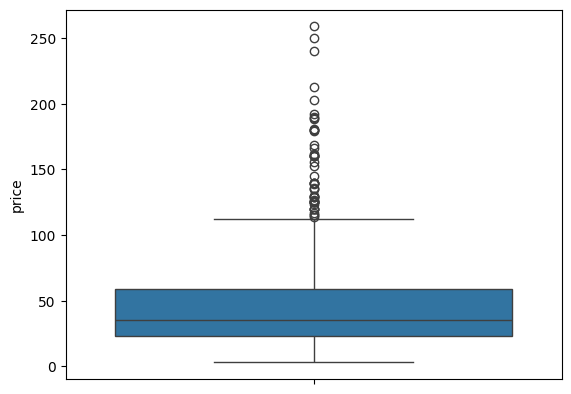

In [170]:
sns.boxplot(y=data_real['price'])#Vertical

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3356\3382692119.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1,1))


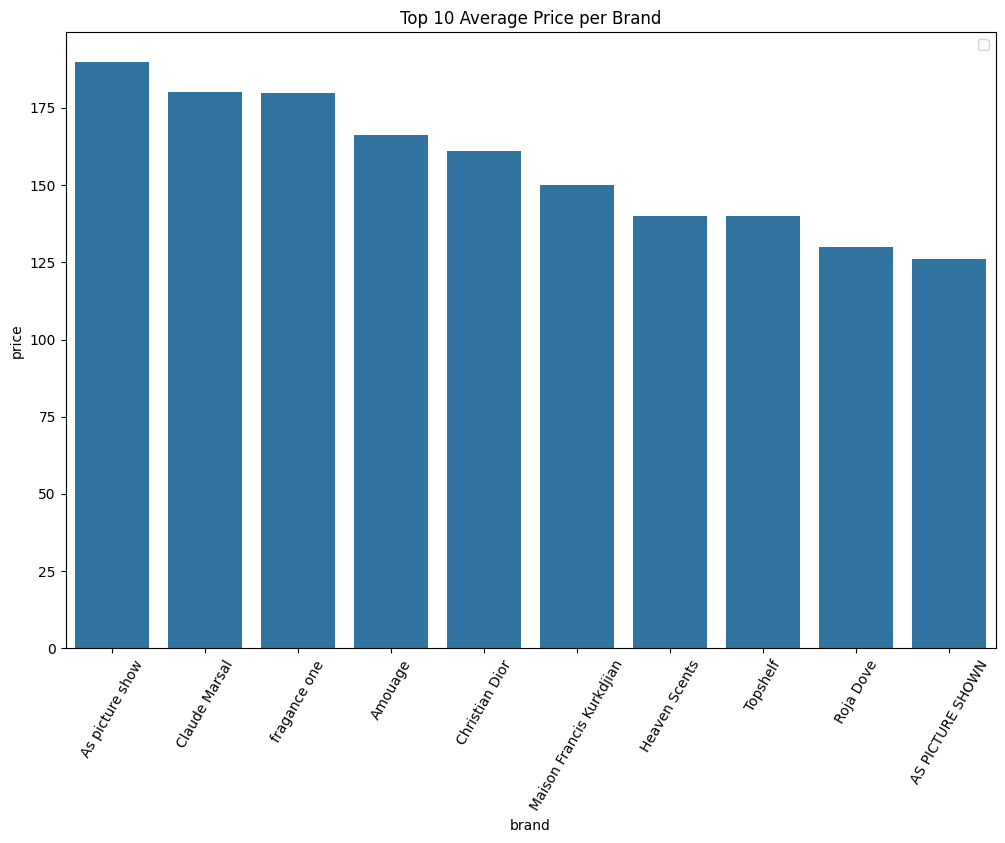

In [160]:
top_10_brand = average_price_brand.head(10)
plt.figure(figsize=(12, 8))

sns.barplot(data=top_10_brand, y='price',  x='brand')

plt.xticks(rotation=60)
plt.title("Top 10 Average Price per Brand")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

Disini kita mengambil top 10 dari data tersebut, lalu dapat dilihat bahwa jumlah rata-rata harga tidak terlalu jauh satu sama lain, dari visualisasi di atas dapat diketahui bahwa brand parfume As picture show menempati urutan pertama dengan rata-rata harga ± 180

### Merek parfum apa saja yang paling diminati?

In [155]:
sum_sold_brand = data_real.groupby('brand')[['sold']].sum().sort_values(by='sold', ascending=False)
sum_sold_brand

,sold
brand,
Calvin Klein,97572.0
Versace,96519.0
Davidoff,54944.0
Azzaro,38305.0
Armaf,24282.0
...,...
Branded,1.0
Hanae Mori,1.0
Victor & Rolf,1.0


untuk menjawab pertanyaan di atas, dibuat dataframe baru bernama sum_sold_brand, disini berisi jumlah parfume terjual berdasarkan brand. Lalu didapatkan tabel seperti di atas.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3356\1366226262.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1,1))


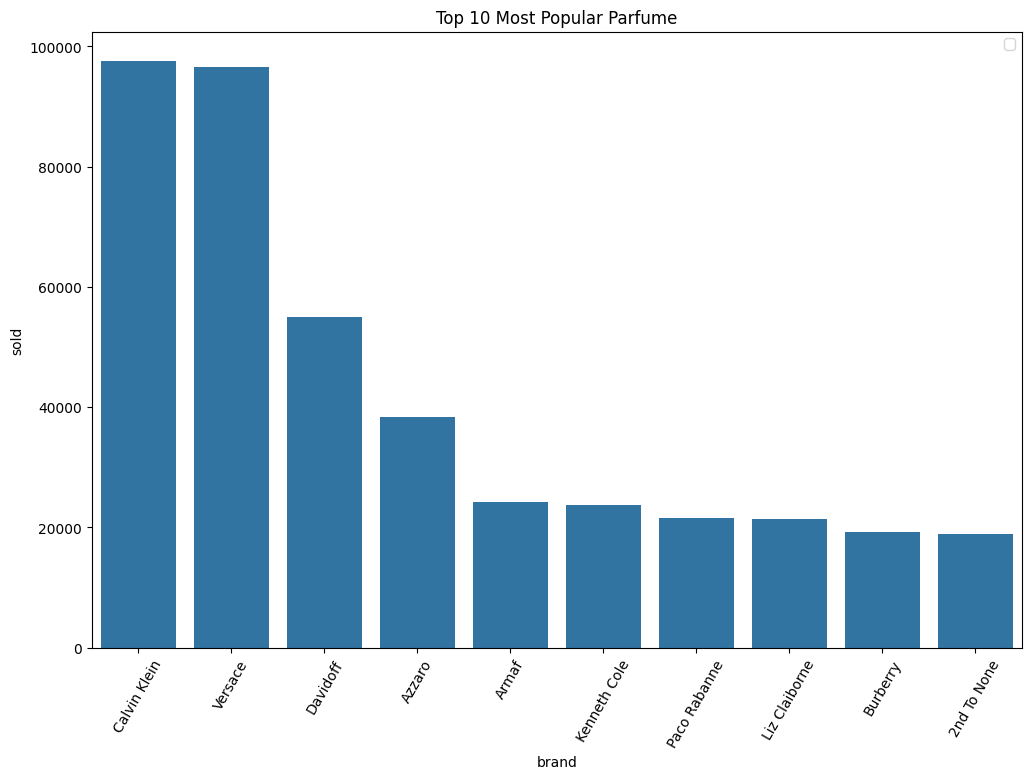

In [156]:
top_10_sold = sum_sold_brand.head(10)
plt.figure(figsize=(12, 8))

sns.barplot(data=top_10_sold, y='sold',  x='brand')

plt.xticks(rotation=60)
plt.title("Top 10 Most Popular Parfume")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

Untuk mengetahui brand apa yang paling diminati diambil 10 data teratas berdasarkan jumlah parfume terjual per brand. Dapat dilihat top 1 dan 2 tidak terlalu jauh, yaitu Calvin Klein dan Versace, lalu disusul dengan brand parfume yang lain. Dapat disimpulkan bahwa brand parfume Calvin Klein dan Versace adalah brand yang paling diminati oleh konsumen.

### Barang apa yang membawa revenue paling tinggi?

In [67]:
revenue_brand = data_real.groupby('brand')[['Sales Revenue']].sum().sort_values(by='Sales Revenue', ascending=False)
revenue_brand 

,Sales Revenue
brand,
Versace,3542617.83
Calvin Klein,2492204.62
Azzaro,1673078.61
Davidoff,1570975.76
Paco Rabanne,972847.28
...,...
The Baron,34.99
Ulric de Varens,22.00
Branded,17.99


Membuat tabel baru yang berisi jumlah sales revenue per brand.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3356\3152701392.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1,1))


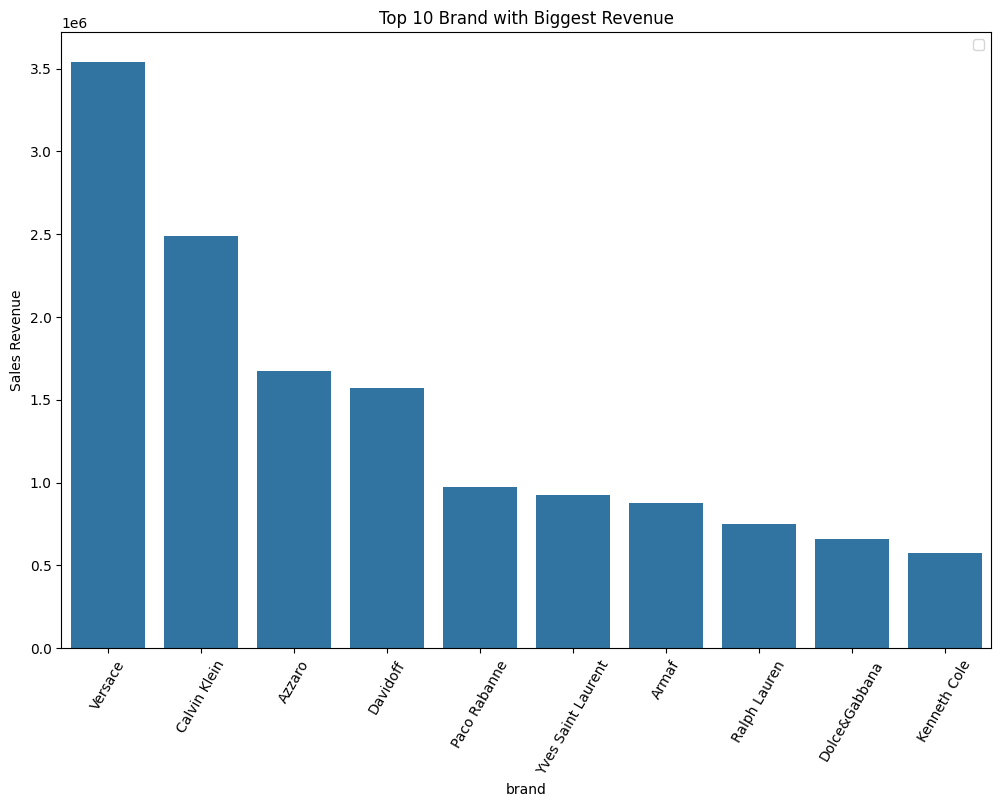

In [147]:
top_10_revenue = revenue_brand.head(10)

plt.figure(figsize=(12, 8))

sns.barplot(data=top_10_revenue, y='Sales Revenue',  x='brand')

plt.xticks(rotation=60)
plt.title("Top 10 Brand with Biggest Revenue")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

Sama seperti dengan analisis sebelumnya tentang parfume paling populer, disini juga top 2 ditempati oleh Versace dan Calvin Klein, dengan pendapatan tertinggi di pegang oleh Versace sekitar 3.5 juta dollar.

Text(0.5, 1.0, 'Bottom 10 with Lowest Revenue')

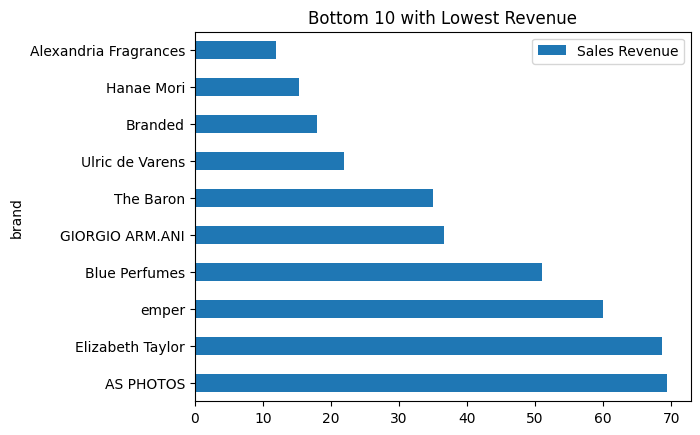

In [148]:
bottom_10_revenue = revenue_brand.tail(10).sort_values(by='Sales Revenue', ascending=False)
bottom_10_revenue.plot(kind='barh').set_title("Bottom 10 with Lowest Revenue")

Dan disini dapat dilihat dari top 10 revenue terbawah. Dilihat dari visualisasi diatas bahwa brand Alexandria Fragrances menjadi brand parfume dengan revenue paling sedikit.

### Bagaimana ketersediaan parfum berkorelasi dengan harga?

In [131]:
data_real.head()

,brand,title,price,currency,available,sold,lastUpdated,itemLocation,Sales Revenue,Kelangkaan Barang
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,84.99,US,10.0,116.0,2024-05-24 10:03:04,"Allen Park, Michigan, United States",9858.84,126.0
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,109.99,US,8.0,48.0,2024-05-23 23:07:49,"Atlanta, Georgia, Canada",5279.52,56.0
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,100.00,US,10.0,27.0,2024-05-22 21:55:43,"Dearborn, Michigan, United States",2700.00,37.0
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,44.99,US,2.0,159.0,2024-05-24 03:30:43,"Reinholds, Pennsylvania, United States",7153.41,161.0
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,16.91,US,0.0,156.0,2024-05-24 07:56:25,"Brooklyn, New York, United States",2637.96,156.0


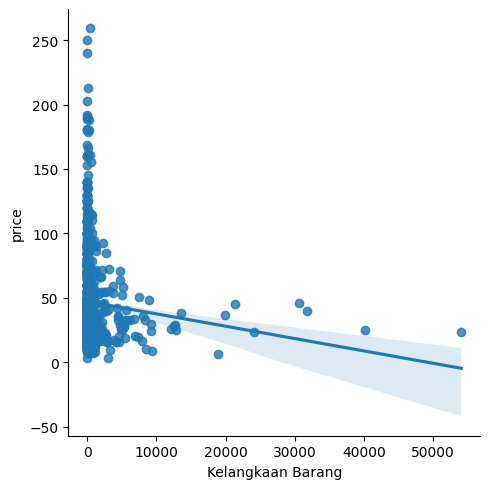

In [120]:
sns.lmplot(data=data_real,x='Kelangkaan Barang', y='price')

Untuk mengetahui korelasi tersebut kita akan mengujinya dengan Pearson. 

In [121]:
corr_r, pval_p = stats.pearsonr(data_real['Kelangkaan Barang'], data_real['price'])
print(f"r-correlation: {corr_r:.2f}, p-value: {pval_p}")


r-correlation: -0.09, p-value: 0.006369112108060129


Dengan menggunakan uji korelasi pearson didapatkan hasil korelasi -0.09 sehingga dapat disimpulkan bahwa ketersediaan parfum tidak berkorelasi dengan harga parfum.

### Brand parfum mana yang paling banyak terdaftar di eBay

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3356\161812655.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1,1))


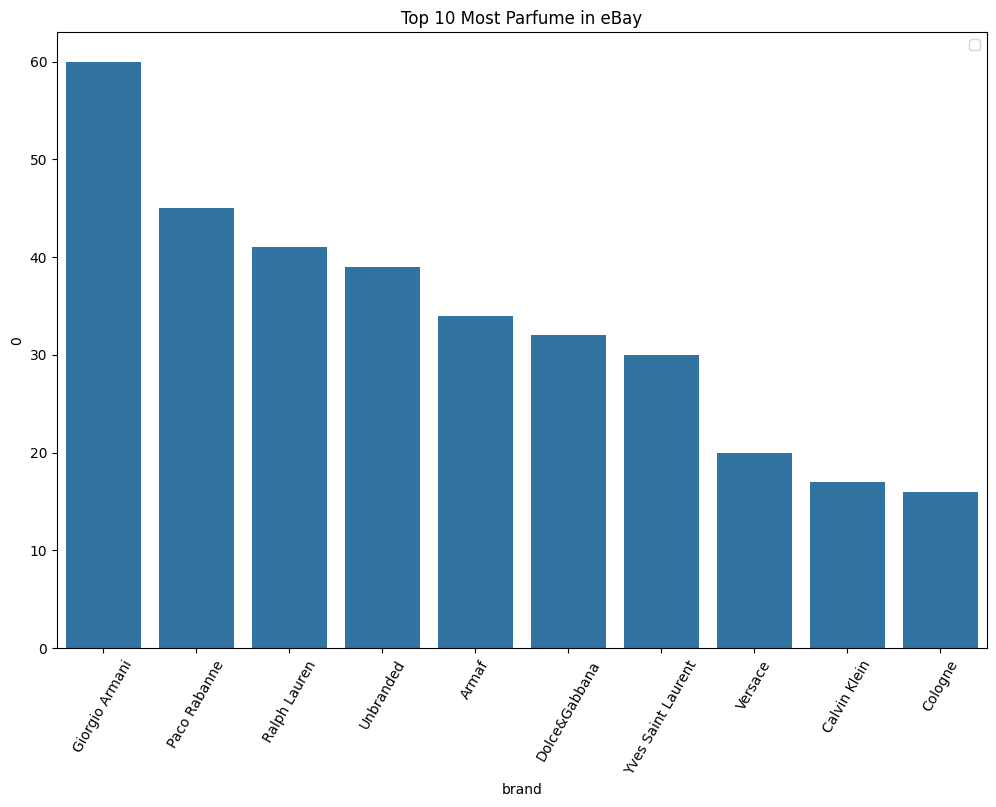

In [154]:
# top_10_most_brand = data_real['brand'].value_counts().head(10)
plt.figure(figsize=(12, 8))

sns.barplot(data=data_real.groupby(['brand']).size().reset_index().sort_values(0, ascending=False).head(10), y=0, x='brand')

plt.xticks(rotation=60)
plt.title("Top 10 Most Parfume in eBay")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

Dari barplot diatas dapat dilihat bahwa brand Giorgio Armani merupakan parfum yang baling banyak terdaftar di eBay.

In [151]:
data_real.groupby(['brand']).size().reset_index().sort_values(0, ascending=False)

,brand,0
95,Giorgio Armani,60
183,Paco Rabanne,45
196,Ralph Lauren,41
221,Unbranded,39
19,Armaf,34
...,...,...
239,king of kings,1
240,rue21,1
241,united scents,1
242,ysl,1


In [100]:
data_real['brand'].value_counts().head(10)

brand
Giorgio Armani        60
Paco Rabanne          45
Ralph Lauren          41
Unbranded             39
Armaf                 34
Dolce&Gabbana         32
Yves Saint Laurent    30
Versace               20
Calvin Klein          17
Cologne               16
Name: count, dtype: int64

### Apakah semakin langka mempengaruhi pembelian?

In [124]:
data_real.head()

,brand,title,price,currency,available,sold,lastUpdated,itemLocation,Sales Revenue,Kelangkaan Barang
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,84.99,US,10.0,116.0,2024-05-24 10:03:04,"Allen Park, Michigan, United States",9858.84,126.0
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,109.99,US,8.0,48.0,2024-05-23 23:07:49,"Atlanta, Georgia, Canada",5279.52,56.0
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,100.00,US,10.0,27.0,2024-05-22 21:55:43,"Dearborn, Michigan, United States",2700.00,37.0
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,44.99,US,2.0,159.0,2024-05-24 03:30:43,"Reinholds, Pennsylvania, United States",7153.41,161.0
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,16.91,US,NaN,156.0,2024-05-24 07:56:25,"Brooklyn, New York, United States",2637.96,156.0


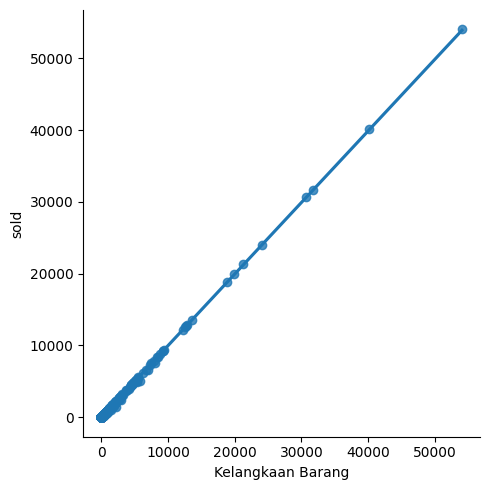

In [122]:
sns.lmplot(data=data_real,x='Kelangkaan Barang', y='sold')

In [133]:
corr_r, pval_p = stats.pearsonr(data_real['Kelangkaan Barang'], data_real['sold'])
print(f"r-correlation: {corr_r:.2f}, p-value: {pval_p}")

r-correlation: 1.00, p-value: 0.0


Dengan menggunakan uji korelasi pearson didapatkan hasil korelasi 1.00 sehingga dapat disimpulkan bahwa kelangkaan sebuah parfum mempengaruhi suatu pembelian.

### Conclusion 

Kesimpulannya untuk para penjual yang ingin berjualan parfum, untuk menentukan strategi apa saja yang harus diambil dan melihat tren pasar, penjual parfum dapat menentukan brand-brand parfum apa saja yang akan dijual nantinya dengan melihat rata-rata harga, brand parfum yang paling populer, brand parfum yang paling banyak terdaftar di market dan juga melihat revenue dari brand tersebut. Selain itu kelangkaan sebuah parfum berpengaruh dalam suatu pembelian yang artinya semakin langka parfum tersebut maka semakin tinggi daya beli konsumen. Dengan kesimpulan tersebut penjual bisa meningkatkan pendapatan mereka dengan mengikuti strategi-strategi tersebut.
